## Project: CNN-based segmentation of cells in multi-modal microscopy images

Contact: Karl Rohr (Heidelberg University K.Rohr@dkfz-heidelberg.de)

### Introduction

Cell segmentation is a central task in biomedical image analysis and enables counting the cell number, quantifying single-cell fluorescence intensity, and tracking of cells to analyze cell motion. Challenges are high variation of cell shape and image intensity, strong image noise, low image contrast, and high cell density. Deep learning methods for cell segmentation in microscopy data show promising results.

### Goal

The goal of this project is to develop a Convolutional Neural Network (CNN) to automatically segment cells in microscopy images. A modified 2D U-Net model (Ronneberger et al., MICCAI 2015, Falk et al., Nature Methods 2019) will be implemented and applied to image data from different imaging modalities comprising fluorescence, differential interference contrast (DIC), and phase-contrast microscopy. Different versions of the network model will be generated by training on data from individual imaging modalities as well as a combination of different imaging modalities. The trained models are applied to the different datasets, and the segmentation accuracy will be quantified by a performance metric. The experimental results are analyzed and a comparison of the different network models will be carried out.

### Data and model

The [2D U-Net model](https://link.springer.com/chapter/10.1007/978-3-319-24574-4_28) will be used as a basis. Zero-padding (SAME padding) in the convolution layers should be included to ensure that the output size of the network is the same as the input size. This eliminates the need for cropping and resizing of the images in the original model. Experiments with different network configurations should be performed (e.g., different number of layers). Besides using a Cross-Entropy Loss as in the original model, a Dice Loss or a combination of both losses should be investigated. Also, loss weighting as in the original model should be tested. Existing implementations of the U-Net can be used as inspiration.

The network model should be applied to [datasets from the Cell Tracking Challenge](https://celltrackingchallenge.net/2d-datasets/) (Ulman et al., Nature Methods 2017) comprising 2D time-lapse microscopy image data of three different imaging modalities:
1. Fluorescence microscopy: HeLa cells stably expressing H2b-GFP ([download](http://data.celltrackingchallenge.net/training-datasets/Fluo-N2DL-HeLa.zip))
2. Differential interference contrast (DIC) microscopy: HeLa cells on a flat glass ([download](http://data.celltrackingchallenge.net/training-datasets/DIC-C2DH-HeLa.zip))
3. Phase-contrast microscopy: Glioblastoma-astrocytoma U373 cells on a polyacrylamide substrate ([download](http://data.celltrackingchallenge.net/training-datasets/PhC-C2DH-U373.zip))

Each dataset consists of two image sequences from which single images should be used as samples. The images can be found in the folders `01` and `02`. Since the "gold truth" provided in the folders `01_GT/SEG` and `02_GT/SEG` is not available for all single images or cells, the "silver truth" in `01_ST/SEG` or `02_ST/SEG`can be used. More information on the datasets can be found [here](https://celltrackingchallenge.net/). One of the two image sequences should be used for training and the other for testing. The labels are instance labels (with a different ID for each cell), which need to be converted to semantic labels (foreground-background).

Different versions of the network model should be generated by training on data from individual imaging modalities as well as a combination of different imaging modalities. A comparison of the different network models should be performed. The Jaccard Index (Intersection over Union) can be used as segmentation performance metric. A strategy needs to be found to deal with large image sizes (e.g., using image resizing or image tiling as in the original model). To improve the segmentation result, different preprocessing and data augmentation strategies can be studied. Information on deep learning for image segmentation and the U-Net is provided in the lecture (Karl Rohr).


### References
Ronneberger 0, Fischer P, Brox T. (2015) [U-Net: Convolutional Networks for Biomedical Image Segmentation](https://link.springer.com/chapter/10.1007/978-3-319-24574-4_28), MICCAI 2015, 234–241

Falk T, Brox T, Ronneberger O et al. (2019) [U-Net: deep learning for cell counting, detection, and morphometry](https://www.nature.com/articles/s41592-018-0261-2), Nature Methods 16, 67-70

Ulman V, Maška M, Harder N, Rohr K, Kozubek M, Ortiz-de-Solorzano C, et al. (2017) [An objective comparison of cell-tracking algorithms](https://www.nature.com/articles/nmeth.4473), Nature Methods 14, 1141–1152




In [1]:
# Install pytorch.lightning and ClearML
%pip install lightning
%pip install clearml
%pip install memory-profiler
%load_ext memory_profiler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 111.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Imports and data loading

In [2]:
# import of necessary libraries
import os
import torch
import scipy
import random
import numpy as np
import seaborn as sns
import torch.nn as nn
from torch.nn import init
import lightning.pytorch as pl
import matplotlib.pyplot as plt
import torch.nn.functional as F

from PIL import Image
from clearml import Task
from copy import deepcopy
from itertools import product
from tqdm.notebook import tqdm
from skimage.transform import resize
from typing import Tuple, List, Dict
from torchvision.transforms import Compose
from torchmetrics.segmentation import MeanIoU
from torch.utils.data import DataLoader, Dataset
from lightning.pytorch.callbacks import ModelCheckpoint

In [3]:
# Settings for ClearML

%env CLEARML_WEB_HOST=https://app.clear.ml/
%env CLEARML_API_HOST=https://api.clear.ml
%env CLEARML_FILES_HOST=https://files.clear.ml
%env CLEARML_API_ACCESS_KEY=7LV78E9ZO25RYVT5N2KBNGLDBN8RHG
%env CLEARML_API_SECRET_KEY=x7iabI85eU32Khl9qxvVm6QBd6ZgjwoVNhmvIj49q-YFFJoUIwYU20bScY4IbDa8d-0

env: CLEARML_WEB_HOST=https://app.clear.ml/
env: CLEARML_API_HOST=https://api.clear.ml
env: CLEARML_FILES_HOST=https://files.clear.ml
env: CLEARML_API_ACCESS_KEY=7LV78E9ZO25RYVT5N2KBNGLDBN8RHG
env: CLEARML_API_SECRET_KEY=x7iabI85eU32Khl9qxvVm6QBd6ZgjwoVNhmvIj49q-YFFJoUIwYU20bScY4IbDa8d-0


In [4]:
# Get Data
# !unzip /content/data/DIC-C2DH-HeLa.zip -d /content/data
# !unzip /content/data//PhC-C2DH-U373.zip -d /content/data
# !unzip /content/data/Fluo-N2DL-HeLa.zip -d /content/data

DATASET_PATH = "/content/data"
CHECKPOINT_PATH = "/content/models"

DIC_PATH = "/DIC-C2DH-HeLa"
PHC_PATH = "/PhC-C2DH-U373"
FLUO_PATH = "/Fluo-N2DL-HeLa"

TRAIN_IMAGE = "/01"
TRAIN_LABELS = "/01_ST"
TRAIN_GOLDEN = "/01_GT"
VAL_IMAGE = "/02"
VAL_LABELS = "/02_ST"

DIC_TRAIN_DATA = DATASET_PATH + DIC_PATH + TRAIN_IMAGE
DIC_TRAIN_GOLDEN = DATASET_PATH + DIC_PATH + TRAIN_GOLDEN
DIC_TRAIN_LABELS = DATASET_PATH + DIC_PATH + TRAIN_LABELS
DIC_VAL_DATA = DATASET_PATH + DIC_PATH + VAL_IMAGE
DIC_VAL_LABELS = DATASET_PATH + DIC_PATH + VAL_LABELS

PHC_TRAIN_DATA = DATASET_PATH + PHC_PATH + TRAIN_IMAGE
PHC_TRAIN_GOLDEN = DATASET_PATH + PHC_PATH + TRAIN_GOLDEN
PHC_TRAIN_LABELS = DATASET_PATH + PHC_PATH + TRAIN_LABELS
PHC_VAL_DATA = DATASET_PATH + PHC_PATH + VAL_IMAGE
PHC_VAL_LABELS = DATASET_PATH + PHC_PATH + VAL_LABELS

FLUO_TRAIN_DATA = DATASET_PATH + FLUO_PATH + TRAIN_IMAGE
FLUO_TRAIN_GOLDEN = DATASET_PATH + FLUO_PATH + TRAIN_GOLDEN
FLUO_TRAIN_LABELS = DATASET_PATH + FLUO_PATH + TRAIN_LABELS
FLUO_VAL_DATA = DATASET_PATH + FLUO_PATH + VAL_IMAGE
FLUO_VAL_LABELS = DATASET_PATH + FLUO_PATH + VAL_LABELS

Archive:  /content/data/DIC-C2DH-HeLa.zip
   creating: /content/data/DIC-C2DH-HeLa/
   creating: /content/data/DIC-C2DH-HeLa/01/
  inflating: /content/data/DIC-C2DH-HeLa/01/t000.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t001.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t002.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t003.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t004.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t005.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t006.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t007.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t008.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t009.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t010.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t011.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t012.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t013.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t014.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t0

In [72]:
# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [6]:
def set_seed(seed: int = 42) -> None:
    """ Function setting the seed.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    pl.seed_everything(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
set_seed(SEED)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


In [7]:
def list_files_in_folder(folder_path: str) -> List[str]:
    """ Function returns a list of paths to
    all files in the given folder.

    Args:
      folder_path (str): Path to the folder.

    Returns:
      file_paths (List[str]): List of file paths.
    """
    file_paths = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_paths.append(os.path.join(root, file))
    return sorted(file_paths)

In [8]:
def get_image_label_paths(data_folder: str,
                          silver_label_folder: str,
                          golden_label_folder: str = None,
                          golden: bool = False) -> Tuple[List[str], List[str], List[bool]]:
    """ Function to get lists of image and label paths, including both silver and
    golden truth when golden=True. Also returns a list indicating if each sample
    is golden truth. If an image has both silver and golden truth labels,
    both pairs are included.

    Args:
        data_folder (str): Path to the image data folder.
        silver_label_folder (str): Path to the silver-truth label data folder
        golden_label_folder (str, optional): Path to the golden-truth label data folder
        golden (bool): If True, include golden-truth labels as well as silver-truth. Defaults to False.

    Returns:
        Tuple[List[str], List[str], List[bool]]: Lists of image paths, corresponding label paths,
                                                 and a list of booleans (True if golden truth, False if silver).
                                                 The order of the returned lists corresponds to the order of samples.
    """
    image_paths = []
    label_paths = []
    is_golden_truth_list = []
    golden_truth_map = {}
    silver_truth_map = {}

    # Golden Truth
    if golden and golden_label_folder:
        golden_seg_folder = os.path.join(golden_label_folder, 'SEG')
        if os.path.exists(golden_seg_folder):
             for root, _, files in os.walk(golden_seg_folder):
                for file in files:
                    if file.startswith('man_seg') and file.endswith('.tif'):
                        try:
                            num_str = file.replace('man_seg', '').replace('.tif', '')
                            frame_number = int(num_str)
                            image_filename = f't{frame_number:03}.tif'
                        except ValueError:
                             print(f"Warning: Could not parse golden label filename '{file}'.")
                             continue

                        found_image_path = None
                        # Search for the corresponding image in data_folder
                        for root_data, _, files_data in os.walk(data_folder):
                            if image_filename in files_data:
                                found_image_path = os.path.join(root_data, image_filename)
                                break

                        if found_image_path:
                            golden_truth_map[found_image_path] = os.path.join(root, file)
                        else:
                            print(f"Warning: Corresponding image '{image_filename}' for golden label '{file}' not found in '{data_folder}'.")
        else:
            print(f"WARNING: Golden truth folder not found at '{silver_seg_folder}'.")


    # Silver Truth
    silver_seg_folder = os.path.join(silver_label_folder, 'SEG')
    if os.path.exists(silver_seg_folder):
        for root, _, files in os.walk(silver_seg_folder):
            for file in files:
                 if file.startswith('man_seg') and file.endswith('.tif'):
                     try:
                         num_str = file.replace('man_seg', '').replace('.tif', '')
                         frame_number = int(num_str)
                         image_filename = f't{frame_number:03}.tif'
                     except ValueError:
                         print(f"WARNING: Could not parse from silver label filename '{file}'.")
                         continue

                     found_image_path = None
                     for root_data, _, files_data in os.walk(data_folder):
                         if image_filename in files_data:
                             found_image_path = os.path.join(root_data, image_filename)
                             break

                     if found_image_path:
                         silver_truth_map[found_image_path] = os.path.join(root, file)
                     else:
                         print(f"WARNING: Corresponding image '{image_filename}' for silver label '{file}' not found in '{data_folder}'.")
    else:
        print(f"WARNING: Silver truth folder not found at '{silver_seg_folder}'.")

    all_image_paths_with_labels = sorted(list(set(golden_truth_map.keys()).union(set(silver_truth_map.keys()))))

    for image_path in all_image_paths_with_labels:
        # Add silver truth
        if image_path in silver_truth_map:
            image_paths.append(image_path)
            label_paths.append(silver_truth_map[image_path])
            is_golden_truth_list.append(False)

        # Mark as golden truth
        if golden and image_path in golden_truth_map:
            image_paths.append(image_path)
            label_paths.append(golden_truth_map[image_path])
            is_golden_truth_list.append(True)


    return image_paths, label_paths, is_golden_truth_list

# Utilities and data augmentation

In [9]:
def plot_images(*args):
    """ Function to plot multiple images for
    different augmentations.
    """
    f,ax = plt.subplots(1,len(args), figsize=(24, 24))
    for i in range(len(args)):
        ax[i].imshow(args[i][0], cmap="inferno")
        ax[i].set_title(args[i][1])
        ax[i].axis("off")
    plt.show()
    plt.close()


def plot_heatmap(data: np.ndarray) -> None:
    """ Function to plot a heatmap of the given data
    or labels.

    Args:
        data (np.ndarray): The data to plot.
    """
    plt.figure(figsize=(12, 6))
    plt.imshow(data, cmap='inferno', interpolation='nearest')
    plt.colorbar()
    plt.show()
    plt.close()


def channel_comparison(tensor: torch.Tensor) -> torch.Tensor:
    """ Function that returns the output of the model as 1 if there is
    foreground at the given position, and zero if background.

    Args:
        tensor (torch.Tensor): The output of the model.

    Returns:
        np.ndarray: The comparison result of foreground and background.
    """
    if tensor.shape != (1, 2, 512, 512):
        raise ValueError("Input tensor must have shape (1, 2, 512, 512)")

    # Extract the first and second channels
    first_channel = tensor[0, 0, :, :]
    second_channel = tensor[0, 1, :, :]

    # Compare the values
    comparison_result = (second_channel > first_channel).numpy().astype(np.uint8)

    return comparison_result


def plot_results(arr1, arr2, arr3):

    # Setting up the figure and axes
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    min_val = min(arr1.min(), arr2.min(), arr3.min())
    max_val = max(arr1.max(), arr2.max(), arr3.max())

    # Creating heatmaps
    sns.heatmap(arr1, ax=axs[0], cbar=False, cmap='viridis')
    axs[0].set_title('Orginal image')
    axs[0].set_xticks([])
    axs[0].set_yticks([])

    sns.heatmap(arr2, ax=axs[1], cbar=False, cmap='viridis', vmin=min_val, vmax=max_val)
    axs[1].set_title('Label')
    axs[1].set_xticks([])
    axs[1].set_yticks([])

    sns.heatmap(arr3, ax=axs[2], cbar=False,cmap='viridis', vmin=min_val, vmax=max_val)
    axs[2].set_title('Model prediction')
    axs[2].set_xticks([])
    axs[2].set_yticks([])

    plt.tight_layout()
    plt.show()

In [10]:
class TIF_dataset_GT(Dataset):

    def __init__(self,
                 image_paths: List[str],
                 label_paths: List[str],
                 is_golden_truth: List[bool],
                 image_transform_standard = None,
                 label_transform_standard = None,
                 image_transform_golden = None,
                 label_transform_golden = None,
                 dataset_maximum = None) -> None:
        """ Class for storing data with the same .tif extension, both silver and
        gold true with different augmentation to optimise training.
        Images are labelled with the specified tags.

        Args:
            image_paths (List[str]): List of image paths.
            label_paths (List[str]): List of label paths.
            is_golden_truth (List[bool]): List of booleans indicating if each
                                          sample is golden truth.
            image_transform_standard (Compose): Image transform for silver data.
            label_transform_standard (Compose): Label transform for silver data.
            image_transform_golden (Compose): Image transform for golden data.
            label_transform_golden (Compose): Label transform for golden data.
            dataset_maximum (int): Maximum value in goal for  normalization.

        Returns:
            None
        """

        self.image_paths = image_paths
        self.label_paths = label_paths
        self.is_golden_truth = is_golden_truth
        self.image_transform_standard = image_transform_standard
        self.label_transform_standard = label_transform_standard
        self.image_transform_golden = image_transform_golden
        self.label_transform_golden = label_transform_golden
        self.dataset_maximum = dataset_maximum

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx: int) -> torch.Tensor:
        image_path = self.image_paths[idx]
        label_path = self.label_paths[idx]
        is_golden_truth = self.is_golden_truth[idx]

        image = Image.open(image_path)
        np_image = np.array(image).astype('float32')

        label = Image.open(label_path)
        np_label = np.array(label).astype('float32')
        np_label = np.where(np_label != 0, 1, 0).astype('float32')


        if is_golden_truth:
            if self.image_transform_golden:
                np_image = self.image_transform_golden(np_image)
            if self.label_transform_golden:
                np_label = self.label_transform_golden(np_label)
        else:
            if self.image_transform_standard:
                np_image = self.image_transform_standard(np_image)
            if self.label_transform_standard:
                np_label = self.label_transform_standard(np_label)

        image_tensor = torch.from_numpy(np_image.copy()).unsqueeze(0).float()
        label_tensor = torch.from_numpy(np_label.copy()).unsqueeze(0).float()

        # Normalizing the images
        if self.dataset_maximum is None:
            image_tensor = (image_tensor - torch.mean(image_tensor)) / torch.std(image_tensor)
        else:
            image_tensor = image_tensor / self.dataset_maximum

        return image_tensor, label_tensor

In [11]:
class TIF_dataset_ST(Dataset):

    def __init__(self,
                 path_list_data,
                 path_list_label,
                 image_transform = None,
                 label_transform = None,
                 dataset_maximum = None):
        """ Class for storing data with the same .tif extension for
        only data silver truth. Images are labelled with the specified tags.

        Args:
            path_list_data (List[str]): List of image paths.
            path_list_label (List[str]): List of label paths.
            image_transform (Compose): Image transform for silver data.
            label_transform (Compose): Label transform for silver data.
            dataset_maximum (int): Maximum value in goal for  normalization.

        Returns:
            None
        """


        self.path_list_data = path_list_data
        self.path_list_label = path_list_label
        self.image_transform = image_transform
        self.label_transform = label_transform
        self.dataset_maximum = dataset_maximum

    def __len__(self):
        return len(self.path_list_data)

    def __getitem__(self, idx):
        image = Image.open(self.path_list_data[idx])
        image_np = np.array(image).astype('float32')
        label = Image.open(self.path_list_label[idx])
        label_np = np.array(label).astype('float32')
        label_np = np.where(label_np != 0, 1, label_np)

        if self.image_transform:
            image_np = self.image_transform(image_np)
            label_np = self.label_transform(label_np)

        image_tensor = torch.from_numpy(image_np.copy()).unsqueeze(0).float()
        label_tensor = torch.from_numpy(label_np.copy()).unsqueeze(0).float()

        if self.dataset_maximum == None:
            image_tensor = (image_tensor - np.mean(image_np))/np.std(image_np) #normalizing the image tensor
        else:
            image_tensor = image_tensor / self.dataset_maximum #normalizing the image tensor

        return image_tensor, label_tensor

In [12]:
X_train_silver = list_files_in_folder(DIC_TRAIN_DATA)
Y_train_silver = list_files_in_folder(DIC_TRAIN_LABELS)
X_val = list_files_in_folder(DIC_VAL_DATA)
Y_val = list_files_in_folder(DIC_VAL_LABELS)

print("Number of training images found:", len(X_train_silver))
print("Number of testing labels found:", len(Y_train_silver))
print("Number of testing images found:", len(X_val))
print("Number of testing labels found:", len(Y_val))

Number of training images found: 84
Number of testing labels found: 84
Number of testing images found: 84
Number of testing labels found: 84


In [13]:
X_train, Y_train, is_golden_train = get_image_label_paths(DIC_TRAIN_DATA,
                                                          DIC_TRAIN_LABELS,
                                                          golden_label_folder=DIC_TRAIN_GOLDEN,
                                                          golden=True
                                    )

print("Number of training images found:", len(X_train))
print("Number of training labels found:", len(Y_train))
print("Number of golden truth flags:", len(is_golden_train))
print("Sample Image Paths:", X_train[:4])
print("Sample Label Paths:", Y_train[:4])
print("Sample Golden Truth Flags:", is_golden_train[:4])

Number of training images found: 93
Number of training labels found: 93
Number of golden truth flags: 93
Sample Image Paths: ['/content/data/DIC-C2DH-HeLa/01/t000.tif', '/content/data/DIC-C2DH-HeLa/01/t001.tif', '/content/data/DIC-C2DH-HeLa/01/t002.tif', '/content/data/DIC-C2DH-HeLa/01/t002.tif']
Sample Label Paths: ['/content/data/DIC-C2DH-HeLa/01_ST/SEG/man_seg000.tif', '/content/data/DIC-C2DH-HeLa/01_ST/SEG/man_seg001.tif', '/content/data/DIC-C2DH-HeLa/01_ST/SEG/man_seg002.tif', '/content/data/DIC-C2DH-HeLa/01_GT/SEG/man_seg002.tif']
Sample Golden Truth Flags: [False, False, False, True]


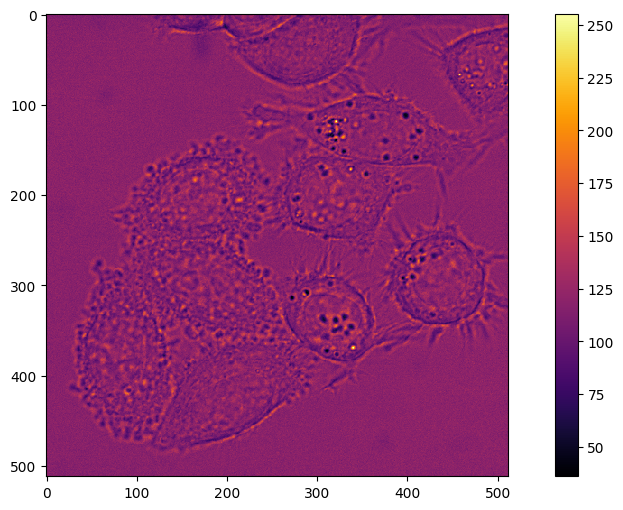

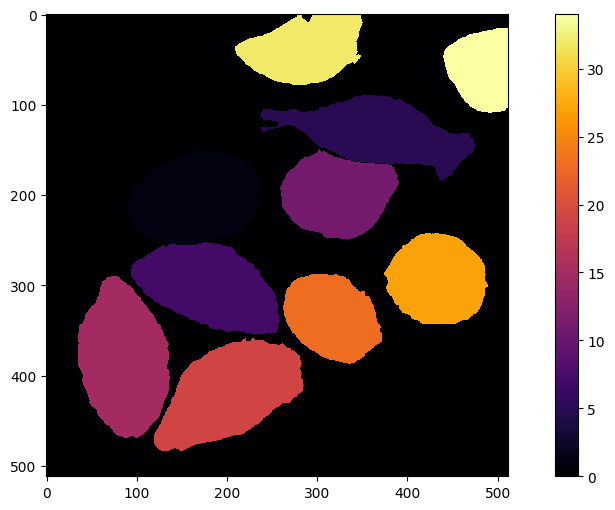

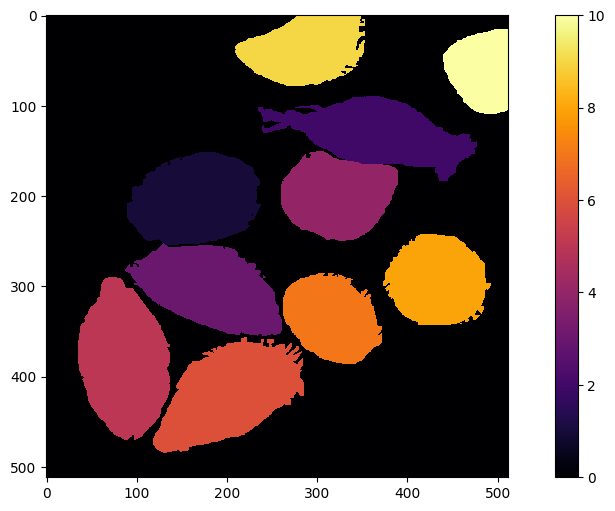

In [14]:
# Schow example image
EXAMPLE_INDEX = 2
image = Image.open(X_train_silver[EXAMPLE_INDEX])
silver_label = Image.open(Y_train_silver[EXAMPLE_INDEX])
golden_label = Image.open(Y_train[EXAMPLE_INDEX + 1])

plot_heatmap(image)
plot_heatmap(silver_label)
plot_heatmap(golden_label)

# Utilities and data augmentation

In [15]:
# Classes for data augmentations

class RandomRotate90():
    def __init__(self,
                 random_state: int,
                 execution_probability: float = 0.0):
        self.random_state = random_state
        self.execution_probability = execution_probability

    def __call__(self, x) -> np.ndarray:
        if self.random_state.random() < self.execution_probability:
            k = self.random_state.randint(1,4)
            return np.rot90(x,k)
        return x


class RandomContrast():
    def __init__(self,
                 random_state: int,
                 scale: float,
                 execution_probability: float = 0.0):
        self.random_state = random_state
        self.execution_probability = execution_probability
        self.scale = scale

    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            lam = self.random_state.uniform(np.max((0, 1 - self.scale)), 1 + self.scale)
            return np.clip(x * lam, 0, 255)
        return x


class RandomBrightness():
    def __init__(self,
                 random_state: int,
                 scale: float,
                 execution_probability: float = 0.0):
        self.random_state = random_state
        self.execution_probability = execution_probability
        self.scale = scale

    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            lam = 255 * self.scale * self.random_state.uniform(-1,1)
            return np.clip(x + lam, 0, 255)
        return x


class RandomElasticDeformation():
    def __init__(self,
                 random_state: int,
                 grid_size: int,
                 sigma: float,
                 order: int,
                 execution_probability: float = 0.0):
        self.random_state = random_state
        self.grid_size = grid_size
        self.sigma = sigma
        self.order = order
        self.execution_probability = execution_probability

    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            h,w = x.shape

            dx = self.random_state.randn(*[self.grid_size, self.grid_size]) * self.sigma
            dy = self.random_state.randn(*[self.grid_size, self.grid_size]) * self.sigma
            dx = resize(dx, x.shape, preserve_range=True, order=3)
            dy = resize(dy, x.shape, preserve_range=True, order=3)

            idx_x, idx_y = np.meshgrid(np.arange(h), np.arange(w))
            coordinates = idx_y + dy, idx_x + dx

            return scipy.ndimage.map_coordinates(x,
                                                 coordinates,
                                                 order=self.order,
                                                 mode="reflect",
                                                 prefilter=False
                    )

        return x


class RandomFlip():
    def __init__(self,
                 random_state: int,
                 execution_probability: float = 0.0):
        self.random_state = random_state
        self.execution_probability = execution_probability

    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            axis = self.random_state.randint(0,2)
            return np.flip(x, axis)
        return x


class RandomRotate():
    def __init__(self,
                 random_state: int,
                 angle_range: float,
                 execution_probability: float = 0.0,
                 mode: str = "mirror",
                 order: int = 0,
                 reshape: bool = False):
        self.random_state = random_state
        self.angle_range = angle_range # Specifing angle range, i.e. [angle_min, angle_max]
        self.execution_probability = execution_probability
        self.mode = mode
        self.order = order
        self.reshape = reshape

    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            angle = self.random_state.uniform(self.angle_range[0], self.angle_range[1])
            return scipy.ndimage.rotate(x, angle, reshape=self.reshape, mode=self.mode, order=self.order)
        return x


class AugmentationPipeline():
    def __init__(self,
                 random_state: bool = None,
                 rotate_p: float = 0.5,
                 elastic_p: float = 0.5,
                 contrast_p: float = 0.5,
                 brightness_p: float = 0.5,
                 contrast_scale: float = 0.1,
                 brightness_scale: float = 0.1) -> Tuple[np.ndarray, np.ndarray]:
        self.rs = np.random.RandomState() if random_state is None else random_state
        self.img_transforms = [
            RandomRotate90(self.rs, rotate_p),
            RandomElasticDeformation(self.rs, grid_size=4, sigma=8, order=1, execution_probability=elastic_p),
            RandomContrast(self.rs, contrast_scale, execution_probability=contrast_p),
            RandomBrightness(self.rs, brightness_scale, execution_probability=brightness_p)
        ]
        self.mask_transforms = [
            RandomRotate90(self.rs, rotate_p),
            RandomElasticDeformation(self.rs, grid_size=4, sigma=8, order=0, execution_probability=elastic_p)
        ]

    def __call__(self, img, mask):
        for t in self.mask_transforms:
            mask = t(mask)
        for t in self.img_transforms:
            img = t(img)
        return img, mask


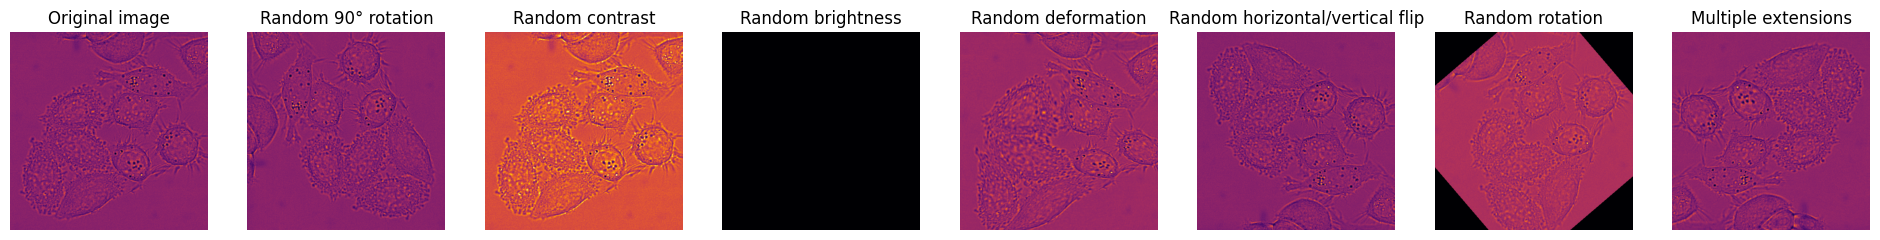

In [16]:
image =  np.array(Image.open(X_train_silver[EXAMPLE_INDEX])).astype('float32')
silver_label = np.array(Image.open(Y_train_silver[EXAMPLE_INDEX])).astype('float32')
golden_label = np.array(Image.open(Y_train[EXAMPLE_INDEX + 1])).astype('float32')

rot90 = RandomRotate90(random_state=np.random.RandomState(SEED),
                       execution_probability=1)(image)
contrast = RandomContrast(random_state=np.random.RandomState(SEED),
                          scale=0.5,
                          execution_probability=1)(image)
brightness = RandomBrightness(random_state=np.random.RandomState(SEED),
                              scale=1,
                              execution_probability=1)(image)
deform = RandomElasticDeformation(random_state=np.random.RandomState(SEED),
                                  grid_size=3,
                                  sigma=25,
                                  order=3,
                                  execution_probability=1)(image)
flip = RandomFlip(random_state=np.random.RandomState(SEED),
                  execution_probability=1)(image)
rot = RandomRotate(random_state=np.random.RandomState(SEED),
                   angle_range=[-45,45],
                   execution_probability=1,
                   mode = "constant")(image)
custom, _ = AugmentationPipeline(random_state=np.random.RandomState(SEED),
                              rotate_p=1,
                              elastic_p=1,
                              contrast_p=1,
                              brightness_p=1)(image, silver_label)

plot_images(
    [image, "Original image"],
    [rot90, "Random 90° rotation"],
    [contrast, "Random contrast"],
    [brightness, "Random brightness"],
    [deform, "Random deformation"],
    [flip, "Random horizontal/vertical flip"],
    [rot, "Random rotation"],
    [custom, "Multiple extensions"]
)

In [17]:
# Example of data augmentation
execution_probability = 0.1

image_transforms_train = Compose([
    RandomRotate90(random_state=np.random.RandomState(SEED), execution_probability=execution_probability),
    RandomElasticDeformation(random_state=np.random.RandomState(SEED), grid_size=3, sigma=10, order=3, execution_probability=execution_probability),
    RandomContrast(random_state=np.random.RandomState(SEED), scale=0.1, execution_probability=execution_probability),
    RandomBrightness(random_state=np.random.RandomState(SEED), scale=0.1, execution_probability=execution_probability)
])

label_transforms_train = Compose([
    RandomRotate90(random_state=np.random.RandomState(SEED), execution_probability=execution_probability),
    RandomElasticDeformation(random_state=np.random.RandomState(SEED), grid_size=3, sigma=10, order=1, execution_probability=execution_probability),
])


golden_image_transforms_train = Compose([
    RandomRotate90(random_state=np.random.RandomState(SEED), execution_probability=execution_probability),
    RandomElasticDeformation(random_state=np.random.RandomState(SEED), grid_size=3, sigma=10, order=3, execution_probability=execution_probability),
    RandomContrast(random_state=np.random.RandomState(SEED), scale=0.1, execution_probability=execution_probability),
    RandomBrightness(random_state=np.random.RandomState(SEED), scale=0)
])

golden_label_transforms_train = Compose([
    RandomRotate90(random_state=np.random.RandomState(SEED), execution_probability=execution_probability),
    RandomElasticDeformation(random_state=np.random.RandomState(SEED), grid_size=2, sigma=20, order=1, execution_probability=execution_probability),
])

# Losses and Metrics

In [18]:
# Losses during training
def Dice(y_true: torch.Tensor, y_pred: torch.Tensor) -> float:
    numerator = 2 * np.sum(y_pred * y_true, axis = (1,2))
    denominator = np.sum(y_pred, axis = (1,2)) + np.sum(y_pred, axis = (1,2))
    return np.mean(numerator / denominator)

def IoU(y_true: torch.Tensor, y_pred: torch.Tensor) -> float:
    numerator = np.sum(y_pred * gt, axis = (1,2))
    denominator = np.sum(y_pred, axis = (1,2)) + np.sum(y_true, axis = (1,2))
    denominator -= np.sum(y_pred * y_true, axis = (1,2))
    return np.mean(numerator / denominator)

def MIoU(y_true, y_pred) -> float:
    intersection = torch.mean((y_true==1).float() * (y_pred==1).float())
    union = torch.mean((y_true==1).float() + (y_pred==1).float()) - intersection
    miou = intersection / union
    return miou

In [19]:
# Classes for loss computation

class DiceLoss(nn.Module):
    def __init__(self):
        super(DiceLoss, self).__init__()

    def forward(self,
                y_pred: torch.Tensor,
                y_true: torch.Tensor,
                eps: float = 1e-8) -> float:
        loss = 1.0

        for c in range(2):
            y_pred_c = y_pred[:, c, :, :]
            y_true_c = (y_true == c).float()
            intersection = torch.sum(y_pred_c * y_true_c)
            union = torch.sum(y_pred_c) + torch.sum(y_true_c)
            dice_coeff = (2 * intersection + eps) / (union + eps)
            loss -= (dice_coeff / 2)

        return loss


class ComboLoss(nn.Module):
    def __init__(self,
                 alpha: float) -> float:
        super(ComboLoss, self).__init__()
        self.dice_loss = DiceLoss()
        self.bce_loss = nn.CrossEntropyLoss()
        self.alpha = alpha

    def forward(self,
                y_pred: torch.Tensor,
                y_true: torch.Tensor) -> float:
        loss = self.alpha * self.dice_loss(y_pred, y_true)
        loss += (1.0 - self.alpha) * self.bce_loss(y_pred, y_true)
        return loss


class LogCoshDiceLoss(nn.Module):
    def __init__(self):
        super(LogCoshDiceLoss, self).__init__()
        self.dice_loss = DiceLoss()

    def forward(self,
                y_pred: torch.Tensor,
                y_true: torch.Tensor) -> float:
        return torch.log(torch.cosh(self.dice_loss(y_pred, y_true)))

In [20]:
train_dataset_DIC_ST = TIF_dataset_ST(X_train_silver, Y_train_silver, image_transforms_train, label_transforms_train)
train_dataloader_DIC_ST = DataLoader(train_dataset_DIC_ST, batch_size=4, shuffle=True, num_workers=2)
val_dataset_DIC_ST = TIF_dataset_ST(X_val, Y_val)
val_dataloader_DIC_ST = DataLoader(val_dataset_DIC_ST, batch_size=32, shuffle=False, num_workers=2)

# Training

In [21]:
def train_model(model, train_dataloader, val_dataloader):
    set_seed(SEED)
    trainer.fit(model, train_dataloader, val_dataloader)
    model.load_state_dict(torch.load(checkpoint.best_model_path, weights_only=True)['state_dict'])
    try:
        model.task.close()
    except AttributeError:
        print("Model didn't has task attribute!")
    except Exception as e:
        print(f"EROR closing task: {e}!")


    return model

def plot_example_output(model, val_dataset):
    data, label = val_dataset[EXAMPLE_INDEX]
    model.eval()
    model.to(device)
    model_output = model.generate_numpy_output_from_single_image(data.unsqueeze(1).to(device))

    print('Model output')
    plot_heatmap(model_output)

    print('Label')
    plot_heatmap(label.squeeze().numpy())

    print('original image')
    plot_heatmap(data.squeeze().numpy())

In [22]:
SIZES = [1, 4, 16, 32]
# Test: SIZES, LOSS_FUNCTION, LR, DROPOUT, INIT_TYPE, GAIN, TASK_NAME

## UNet

In [23]:
# Initialize weights

def init_weights(m, init_type='normal', gain=0.01):
    classname = m.__class__.__name__
    if hasattr(m, 'weight') and (classname.find('Conv') != -1 or classname.find('Linear') != -1):
        if init_type == 'normal':
            init.normal_(m.weight.data, 0.0, gain)
        elif init_type == 'xavier':
            init.xavier_normal_(m.weight.data, gain=gain)
        elif init_type == 'kaiming':
            init.kaiming_normal_(m.weight.data, a=0, mode='fan_in')
        elif init_type == 'orthogonal':
            init.orthogonal_(m.weight.data, gain=gain)
        elif init_type == 'custom':
            if classname.find('Conv') != -1:
                kernel_size = m.kernel_size
                in_channels = m.in_channels
                N = kernel_size[0] * kernel_size[1] * in_channels
            elif classname.find('Linear') != -1:
                N = m.in_features

            std_dev = (2.0 / N)**0.5
            init.normal_(m.weight.data, 0.0, std_dev)
        else:
            raise NotImplementedError(f"Initialization method [{init_type}] is not implemented")
        if hasattr(m, 'bias') and m.bias is not None:
            init.constant_(m.bias.data, 0.0)

    elif classname.find('BatchNorm2d') != -1:
        init.normal_(m.weight.data, 1.0, gain)
        init.constant_(m.bias.data, 0.0)

In [24]:
class Convolutional_Block(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 kernel_size=3,
                 dropout=0.1):
        super(Convolutional_Block, self).__init__()
        padding = kernel_size // 2  # SAME padding
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding, bias=True)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding, bias=True)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding, bias=True)
        self.bn3 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout(p=dropout)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        residual = x
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.dropout(x)
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.dropout(x)
        return x + residual

In [25]:
class UNet(pl.LightningModule):
    def __init__(self,
                 channel_list: List[int],
                 crop: bool = None,
                 loss_fn: torch.nn = nn.CrossEntropyLoss(),
                 lr: float = 1e-3,
                 betas: Tuple[float, float] = (0.9, 0.999),
                 kernel_size: int = 3,
                 dropout:float = 0.1,
                 len_train: int = 1,
                 len_val: int = 1,
                 init_type: str = "normal",
                 gain: float = 0.01,
                 log: bool = False,
                 task_name: str = None):
        super().__init__()
        self.lr, self.betas = lr, betas
        self.crop = crop
        self.loss_fn = loss_fn
        self.allow_log = log
        self.len_train = len_train
        self.len_val = len_val
        self.kernel_size = kernel_size
        self.dropout = dropout
        self.train_loss_accum = 0.0
        self.train_miou_accum = 0.0
        self.val_loss_accum = 0.0
        self.val_miou_accum = 0.0

        # Set up ClearML
        self.task = None
        if task_name is not None:
            params = {"model": self.__class__.__name__,
                      "lr": lr,
                      "betas": betas,
                      "droput": dropout,
                      "loss_fn": loss_fn.__class__.__name__,
                      "init_type": init_type,
                      "gain": gain,
                      "batch_train": len_train,
                      "batch_val": len_val
            }
            self.task = Task.init(project_name="CNN-based segmentation",
                                  task_name=task_name)
            self.clearml_logger = self.task.get_logger()

        self.channel_list = deepcopy(channel_list)

        # Encoder
        self.channel_sizes = [(channel_list[i], channel_list[i+1]) for i in range(len(channel_list)-1)]
        self.bottom_path = nn.ModuleList([
            Convolutional_Block(c_in, c_out, kernel_size, dropout)
            for c_in, c_out in self.channel_sizes
        ])

        # Bootleneck
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = Convolutional_Block(channel_list[-1], channel_list[-1], kernel_size, dropout)

        # Decoder
        self.channel_sizes[0] = (2, channel_list[1])
        self.channel_sizes = list(reversed(self.channel_sizes))
        self.up_convs = nn.ModuleList()
        self.top_path = nn.ModuleList()
        for out_ch, in_ch in self.channel_sizes:
            self.up_convs.append(nn.ConvTranspose2d(in_ch, in_ch, 2, stride=2))
            self.top_path.append(Convolutional_Block(in_ch, out_ch, kernel_size, dropout))

        # Initialize weights
        self.apply(lambda m: init_weights(m, init_type, gain))

    def forward(self, x):
        residuals = []
        for block in self.bottom_path:
            x = block(x)
            residuals.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        residuals = residuals[::-1]

        for idx, block in enumerate(self.top_path):
            x = self.up_convs[idx](x)
            x = x + residuals[idx]
            x = block(x)

        return F.softmax(x, dim=1)

    def training_step(self, batch):
        img, mask = batch
        if self.crop:
            img  = img[:, :, :self.crop, :self.crop]
            mask = mask[:, :, :self.crop, :self.crop]

        mask = mask.squeeze(1).long()
        out  = self(img)
        miou_train = MIoU(out.argmax(1), mask)
        loss = self.loss_fn(out, mask)
        self.train_loss_accum += loss.item()
        self.train_miou_accum += miou_train
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log('train_miou', miou_train, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch):
        img, mask = batch
        if self.crop:
            img  = img[:, :, :self.crop, :self.crop]
            mask = mask[:, :, :self.crop, :self.crop]

        mask = mask.squeeze(1).long()
        out  = self(img)
        loss = self.loss_fn(out, mask)
        miou_val = MIoU(out.argmax(1), mask)
        self.val_loss_accum += loss.item()
        self.val_miou_accum += miou_val
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_miou', miou_val, on_epoch=True, prog_bar=True)
        return loss

    def on_validation_epoch_end(self):
        epoch = int(self.current_epoch)
        avg_loss = self.val_loss_accum / self.len_val
        avg_miou = self.val_miou_accum / self.len_val
        self.log('Mean Validation MIoU', self.val_miou_accum/self.len_val, on_step=False, on_epoch=True, prog_bar=True)
        if self.allow_log:
            print(f'Epoch {self.current_epoch}, Validation loss: {self.val_loss_accum/self.len_val}, Validation MIoU: {self.val_miou_accum/self.len_val}')

        if hasattr(self, 'clearml_logger') and self.clearml_logger:
            self.clearml_logger.report_scalar("Loss", "Validation", iteration=epoch, value=avg_loss)
            self.clearml_logger.report_scalar("MIoU", "Validation", iteration=epoch, value=avg_miou)

        self.val_loss_accum = 0.0
        self.val_miou_accum = 0.0

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr, betas=self.betas)
        return optimizer

    def on_train_epoch_end(self):
        epoch = int(self.current_epoch)
        if self.allow_log:
            print(f'Epoch {self.current_epoch}, Training loss: {self.train_loss_accum/self.len_train}, Training MIoU: {self.train_miou_accum/self.len_train}')

        if hasattr(self, 'clearml_logger') and self.clearml_logger:
            self.clearml_logger.report_scalar("Loss", "Training", iteration=int(self.current_epoch), value=self.train_loss_accum/self.len_train)
            self.clearml_logger.report_scalar("MIoU", "Training", iteration=int(self.current_epoch), value=self.train_miou_accum/self.len_train)

        self.train_miou_accum = 0.0
        self.train_loss_accum = 0.0

    def generate_numpy_output_from_single_image(self, img):
        return channel_comparison(self(img).detach().cpu())

ClearML Task: created new task id=ac356438a56b4cb6933a5ff8b237f694
2025-05-24 11:25:35,309 - clearml.Task - INFO - Storing jupyter notebook directly as code
ClearML results page: https://app.clear.ml/projects/5bef593faa9547b598bd6a01eea31fc8/experiments/ac356438a56b4cb6933a5ff8b237f694/output/log


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: UserWarning:

Checkpoint directory /content/models exists and is not empty.

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name        | Type                | Params | Mode 
------------------------------------------------------------
0 | loss_fn     | LogCoshDiceLoss     | 0      | train
1 | bottom_path | ModuleList          | 29.0 K | train
2 | pool      

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Epoch 0, Validation loss: 0.08054465552171071, Validation MIoU: 0.2136095017194748


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 30, Validation loss: 0.0200820155441761, Validation MIoU: 0.6914259195327759
Epoch 30, Training loss: 0.0043741393102599046, Training MIoU: 0.8914102911949158


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=32` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=32` reached.


Epoch 31, Validation loss: 0.006863159437974294, Validation MIoU: 0.8419547080993652
Epoch 31, Training loss: 0.004195535233953879, Training MIoU: 0.892767608165741
Model output


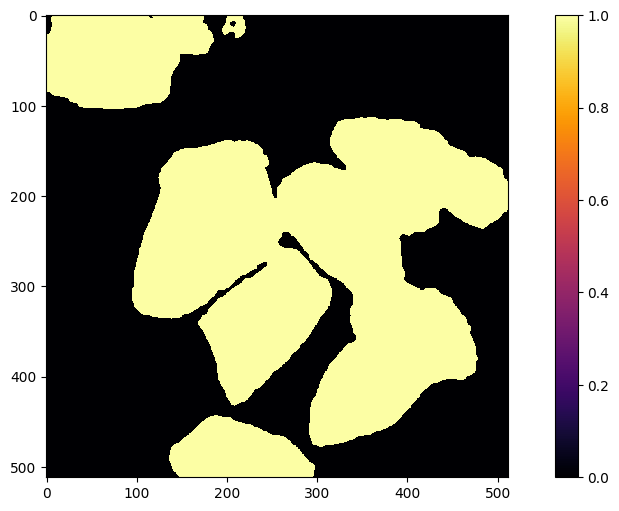

Label


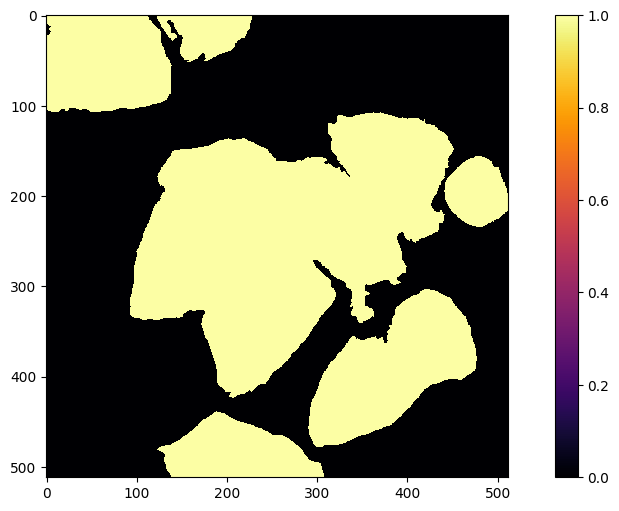

original image


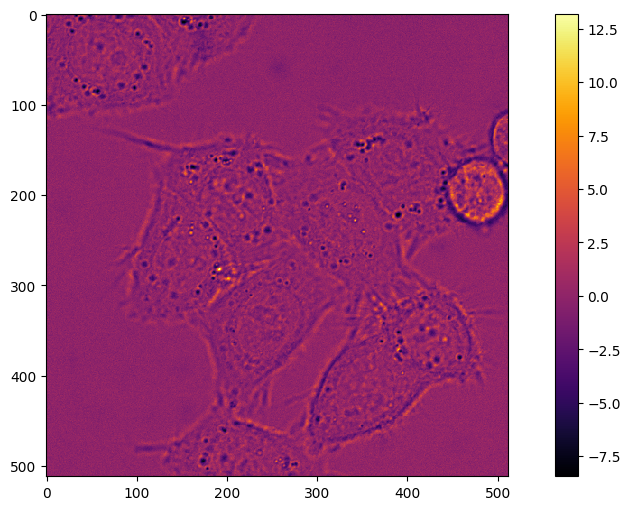

In [ ]:
model = UNet(channel_list=SIZES,
            len_train=len(train_dataloader_DIC_ST),
            len_val=len(val_dataloader_DIC_ST),
            loss_fn=LogCoshDiceLoss(),
            lr=1e-3,
            dropout=0.1,
            init_type="normal",
            gain=0.02,
            log=True,
            task_name='Vanilla U-Net'
        ).to(device)

checkpoint = ModelCheckpoint(dirpath=CHECKPOINT_PATH,
                             save_top_k=2,
                             monitor="Mean Validation MIoU",
                             mode="max"

)
trainer = pl.Trainer(max_epochs=32,
                     log_every_n_steps=1,
                     callbacks=[checkpoint]
)

model = train_model(model, train_dataloader_DIC_ST, val_dataloader_DIC_ST)
plot_example_output(model, val_dataset_DIC_ST)

## UNet++ https://arxiv.org/pdf/1807.10165

In [26]:
class UNetPlus(UNet):

    def __init__(self,
                 channel_list,
                 crop = None,
                 loss_fn = torch.nn.CrossEntropyLoss(),
                 lr = 0.001,
                 betas = (0.9, 0.999),
                 kernel_size=3,
                 dropout = 0.1,
                 log = False,
                 len_train = 1,
                 len_val = 1,
                 init_type: str = "normal",
                 gain: float = 0.01,
                 task_name: str = None):
        super(UNetPlus, self).__init__(
            channel_list,
            crop=crop,
            loss_fn=loss_fn,
            lr=lr,
            betas=betas,
            kernel_size=kernel_size,
            dropout=dropout,
            len_train=len_train,
            len_val=len_val,
            init_type=init_type,
            gain=gain,
            log=log,
            task_name=task_name
        )
        self.horizontal_blocks = nn.ModuleList()
        self.channel_list[0] = 2
        for i in range(len(self.bottom_path)):
            self.horizontal_blocks.append(nn.ModuleList([
                Convolutional_Block(self.channel_list[j], self.channel_list[j], dropout=dropout)
                for j in range(len(self.channel_list)-i-1)]))
        self.horizontal_blocks[0][0] = Convolutional_Block(1, self.channel_list[0], dropout=dropout)

        self.match_chanels = nn.ModuleList([
            nn.Conv2d(channel_list[i+1], channel_list[i], kernel_size=1)
            for i in range(len(channel_list)-1)
        ])

        # Initialize weights
        self.apply(lambda m: init_weights(m, init_type, gain))


    def forward(self, x):
        residuals = [x]
        for i, module in enumerate(self.bottom_path):
            x = module(x)
            residuals.append(x)
            if i < len((self.bottom_path)):
                x = self.pool(x)
        residuals_skip = [res.clone() for res in residuals]
        res = []

        for i in range(len(self.horizontal_blocks)):
            for j in range(len(self.horizontal_blocks[i])):
                prev = F.interpolate(residuals[j+1], residuals[j].shape[-2:], mode="bilinear")
                prev = self.match_chanels[j](prev)
                residuals[j] = self.horizontal_blocks[i][j](residuals[j]+prev)
                if j == 0:
                    res.append(residuals[j])
        residuals.reverse()
        residuals_skip.reverse()
        x = self.bottleneck(x)

        for i, module in enumerate(self.top_path):
            if i >= 0:
                x = self.up_convs[i](x)
            x = x + residuals[i] + residuals_skip[i]
            x = module(x)

        res.append(x)
        res = [F.softmax(r, dim = 1) for r in res]

        return res

    def training_step(self, batch):
        inputs, labels = batch

        if self.crop != None:
            inputs = inputs[:, :, :self.crop, :self.crop]
            labels = labels[:, :, :self.crop, :self.crop]

        labels = labels.squeeze().long()
        outputs = self.forward(inputs)
        loss = 0
        miou_train = 0
        for o in outputs:
            loss += self.loss_fn(o, labels)

        loss /= len(outputs)
        miou_train += MIoU(outputs[-1].argmax(1), labels)

        self.train_loss_accum += loss.item()
        self.train_miou_accum += miou_train

        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log('train_miou', miou_train, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch):
        self.eval()
        with torch.no_grad():
            inputs, labels = batch

            if self.crop != None:
                inputs = inputs[:, :, :self.crop, :self.crop]
                labels = labels[:, :, :self.crop, :self.crop]

            labels = labels.squeeze().long()
            outputs = self.forward(inputs)
            loss = 0
            for o in outputs:
                loss += self.loss_fn(o, labels)
            loss /= len(outputs)

            self.val_loss_accum += loss
            self.val_miou_accum += MIoU(outputs[-1].argmax(1), labels)

            self.log('Validation Loss', loss, on_step=True, on_epoch=True, prog_bar=True)
            self.log('Validation MIoU', self.val_miou_accum, on_step=True, on_epoch=True, prog_bar=True)
            return loss

    def generate_numpy_output_from_single_image(self, img):
        model_return_numpy = channel_comparison(self(img)[-1].detach().cpu())
        return model_return_numpy

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: UserWarning:

Checkpoint directory /content/models exists and is not empty.

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name              | Type                | Params | Mode 
------------------------------------------------------------------
0 | loss_fn           | LogCoshDiceLoss     | 0      | train
1 | bottom_path       | ModuleList          | 29.0 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Epoch 0, Validation loss: 0.07934990525245667, Validation MIoU: 0.18691357970237732


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 14, Validation loss: 0.02014189213514328, Validation MIoU: 0.7998309135437012
Epoch 14, Training loss: 0.025230976265101207, Training MIoU: 0.8111501336097717


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=16` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=16` reached.


Epoch 15, Validation loss: 0.025242138653993607, Validation MIoU: 0.6868731379508972
Epoch 15, Training loss: 0.024781508548628716, Training MIoU: 0.8101493716239929
Model output


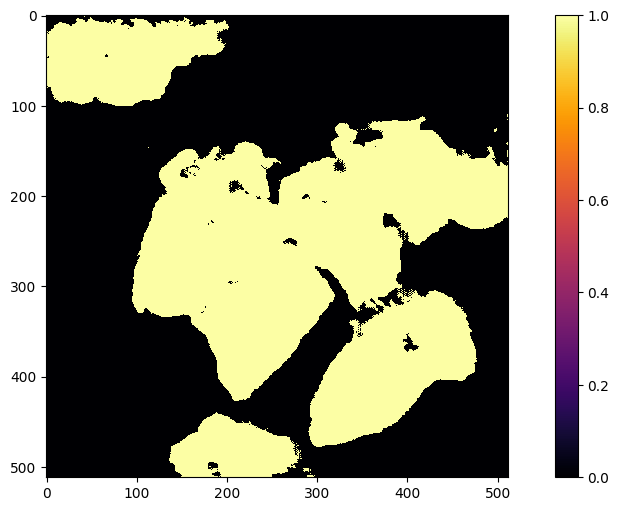

Label


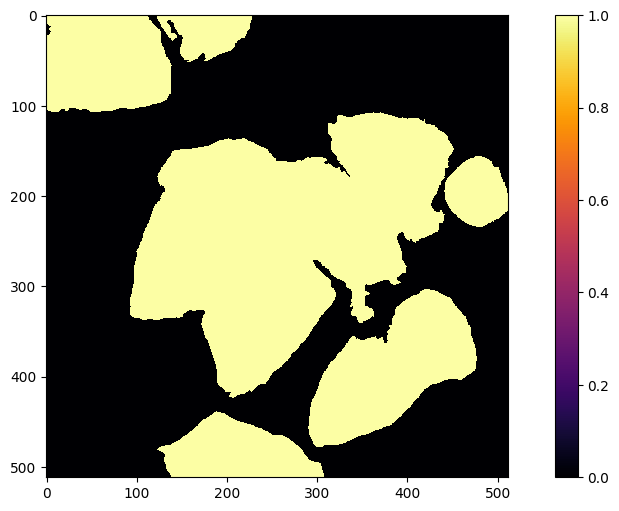

original image


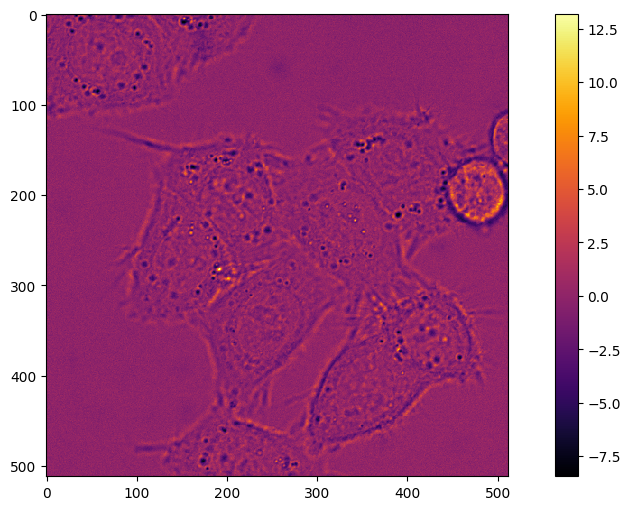

In [ ]:
model = UNetPlus(channel_list=SIZES,
                len_train=len(train_dataloader_DIC_ST),
                len_val=len(val_dataloader_DIC_ST),
                loss_fn=LogCoshDiceLoss(),
                lr=1e-3,
                dropout=0.15,
                init_type='custom',
                gain=0.02,
                log=True,
                task_name='U-Net++'
            ).to(device)

checkpoint = ModelCheckpoint(dirpath=CHECKPOINT_PATH,
                             save_top_k=2,
                             monitor="Mean Validation MIoU",
                             mode="max"

)
trainer = pl.Trainer(max_epochs=16,
                     log_every_n_steps=1,
                     callbacks=[checkpoint]
)

model = train_model(model, train_dataloader_DIC_ST, val_dataloader_DIC_ST)
model.eval()
plot_example_output(model, val_dataset_DIC_ST)

## Attention UNet https://arxiv.org/pdf/1804.03999

In [27]:
class AttentionBlock(nn.Module):
    def __init__(self, current_channel, lower_channel):
        super(AttentionBlock, self).__init__()
        self.current_channel = current_channel
        self.lower_channel = lower_channel
        self.conv1 = nn.Conv2d(current_channel, lower_channel, kernel_size=1, stride=1 if current_channel == 1 else 2) # last 2 levels have the same size
        self.conv2 = nn.Conv2d(lower_channel, lower_channel, kernel_size=1)
        self.conv3 = nn.Conv2d(lower_channel, lower_channel, kernel_size=1)
        self.bn = nn.BatchNorm2d(lower_channel)
        self.dropout = nn.Dropout(p=0.5, inplace=False)

    def forward(self, x, residual):
        x0 = x.clone()
        x = self.conv1(residual) + self.conv2(x)
        x = torch.relu(x)
        x = self.dropout(x)
        x = self.bn(x)
        x = self.conv3(x)
        x = torch.sigmoid(x)
        x = F.interpolate(x, x0.shape[-2:], mode="bilinear")
        return x0 * x

In [79]:
 class AttentionUNet(UNet):
    def __init__(self,
                 channel_list,
                 crop=None,
                 loss_fn=torch.nn.CrossEntropyLoss(),
                 lr=0.001,
                 betas=(0.9, 0.999),
                 kernel_size=3,
                 dropout=0.1,
                 log=False,
                 len_train=1,
                 len_val=1,
                 init_type: str = "normal",
                 gain: float = 0.02,
                 task_name: str = None):
        super(AttentionUNet, self).__init__(
                            channel_list,
                            crop=crop,
                            loss_fn=loss_fn,
                            lr=lr,
                            betas=betas,
                            kernel_size=kernel_size,
                            dropout=dropout,
                            len_train=len_train,
                            len_val=len_val,
                            init_type=init_type,
                            gain=gain,
                            log=log,
                            task_name=task_name
        )
        self.attention_blocks = nn.ModuleList([
            AttentionBlock(current_channel, lower_channel)
            for current_channel, lower_channel in zip(self.channel_list[::-1][1:], self.channel_list[::-1][:-1])
        ])

        # Initialize weights
        self.apply(lambda m: init_weights(m, init_type, gain))

    def forward(self, x):
        residuals = [x]
        for i, module in enumerate(self.bottom_path):
            x = module(x)
            residuals.append(x)
            if i < len((self.bottom_path)):
                x = self.pool(x)

        residuals.pop(-1)
        residuals.reverse()
        x = self.bottleneck(x)

        for i, module in enumerate(self.top_path):
            x = self.up_convs[i](x)
            x = x + self.attention_blocks[i](x, residuals[i])
            x = module(x)

        x = F.softmax(x, dim=1)

        return x

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: UserWarning:

Checkpoint directory /content/models exists and is not empty.

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name             | Type                | Params | Mode 
-----------------------------------------------------------------
0 | loss_fn          | DiceLoss            | 0      | train
1 | bottom_path      | ModuleList          | 29.0 K | 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Epoch 0, Validation loss: 0.3342942992846171, Validation MIoU: 0.0


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 14, Validation loss: 0.30104899406433105, Validation MIoU: 0.5699454545974731
Epoch 14, Training loss: 0.18128061436471485, Training MIoU: 0.7901744246482849


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=16` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=16` reached.


Epoch 15, Validation loss: 0.3888003428777059, Validation MIoU: 0.395286500453949
Epoch 15, Training loss: 0.17965454288891383, Training MIoU: 0.7909923195838928
Model output


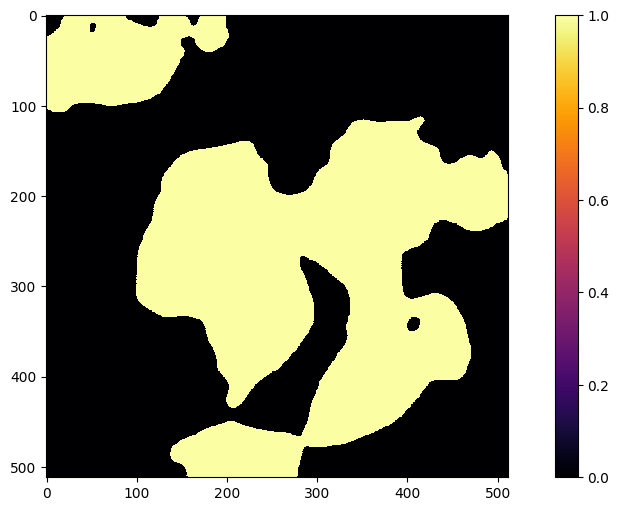

Label


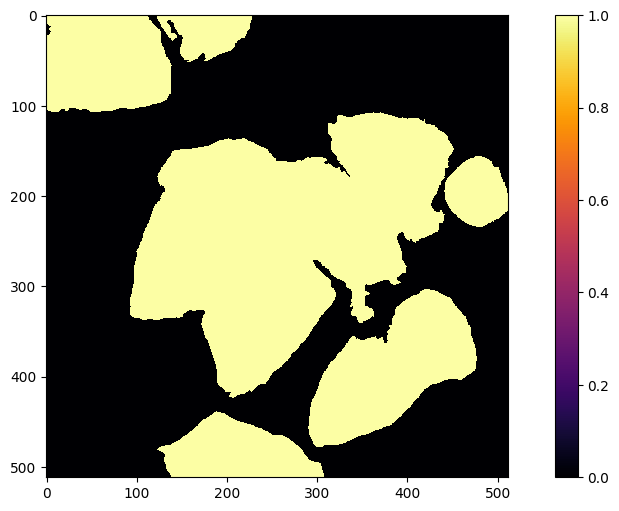

original image


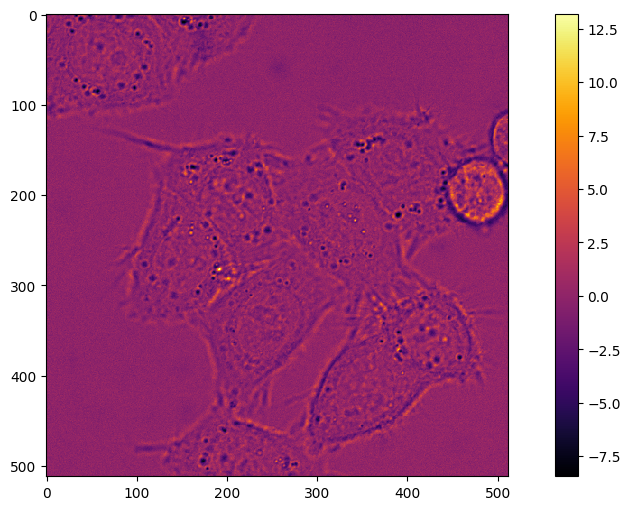

In [ ]:
model = AttentionUNet(channel_list=SIZES,
                      len_train=len(train_dataloader_DIC_ST),
                      len_val=len(val_dataloader_DIC_ST),
                      loss_fn=DiceLoss(),
                      lr=3e-4,
                      dropout=0.15,
                      init_type='xavier',
                      gain=0.02,
                      log=True,
                      task_name='Attention U-Net++'
                  ).to(device)

checkpoint = ModelCheckpoint(dirpath=CHECKPOINT_PATH,
                             save_top_k=2,
                             monitor="Mean Validation MIoU",
                             mode="max"

)
trainer = pl.Trainer(max_epochs=16,
                     log_every_n_steps=1,
                     callbacks=[checkpoint]
)

model = train_model(model, train_dataloader_DIC_ST, val_dataloader_DIC_ST)
model.eval()
plot_example_output(model, val_dataset_DIC_ST)

# RRCNN https://arxiv.org/pdf/1802.06955

In [29]:
class RRCNN_block(nn.Module):
    def __init__(self, in_channels, out_channels, t=2, kernel_size=3, dropout=0.1):
        super().__init__()
        self.t = t
        padding = kernel_size // 2

        # Like in Convolution Block
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding)
        self.bn3 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout(p=dropout)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        residual = x

        # Recurrent loop
        for _ in range(self.t):
            x = self.relu(self.bn2(self.conv2(x + residual)))  # Residual connection
            x = self.dropout(x)
            x = self.relu(self.bn3(self.conv3(x)))
            x = self.dropout(x)

        return x + residual

In [80]:
class RRUNet(UNet):
    def __init__(self,
                 channel_list: List[int],
                 crop: bool = None,
                 loss_fn: torch.nn = nn.CrossEntropyLoss(),
                 t: int = 2,
                 lr: float = 1e-3,
                 betas: Tuple[float, float] = (0.9, 0.999),
                 kernel_size: int = 3,
                 dropout: float = 0.1,
                 len_train: int = 1,
                 len_val: int = 1,
                 init_type: str = "normal",
                 gain: float = 0.01,
                 log: bool = False,
                 task_name: str = None):

        super(RRUNet, self).__init__(
            channel_list=channel_list,
            crop=crop,
            loss_fn=loss_fn,
            lr=lr,
            betas=betas,
            kernel_size=kernel_size,
            dropout=dropout,
            len_train=len_train,
            len_val=len_val,
            init_type=init_type,
            gain=gain,
            log=log,
            task_name=task_name
        )

        # Encoder with RRCNN
        self.channel_sizes = [(channel_list[i], channel_list[i+1]) for i in range(len(channel_list)-1)]
        self.bottom_path = nn.ModuleList([
            RRCNN_block(c_in, c_out, t, kernel_size, dropout)
            for c_in, c_out in self.channel_sizes
        ])

        # Bottleneck with RRCNN
        self.bottleneck = RRCNN_block(channel_list[-1], channel_list[-1], t, kernel_size, dropout)

        # Decoder with RRCNN
        self.channel_sizes[0] = (2, channel_list[1])
        self.channel_sizes = list(reversed(self.channel_sizes))
        self.up_convs = nn.ModuleList()
        self.top_path = nn.ModuleList()
        for out_ch, in_ch in self.channel_sizes:
            self.up_convs.append(nn.ConvTranspose2d(in_ch, in_ch, 2, stride=2))
            self.top_path.append(RRCNN_block(in_ch, out_ch, t, kernel_size, dropout))

        # Reinitialize weights
        self.apply(lambda m: init_weights(m, init_type, gain))

ClearML Task: created new task id=df88f216c3854603ae035b16733f5fae
2025-05-24 23:22:09,371 - clearml.Task - INFO - Storing jupyter notebook directly as code
ClearML results page: https://app.clear.ml/projects/5bef593faa9547b598bd6a01eea31fc8/experiments/df88f216c3854603ae035b16733f5fae/output/log


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name        | Type            | Params | Mode 
--------------------------------------------------------
0 | loss_fn     | LogCoshDiceLoss | 0      | train
1 | bottom_path | ModuleList      | 29.0 K | train
2 | pool        | MaxPool2d       | 0      | train
3 | bottleneck  | RRCNN_block     | 27.9 K | train
4 | up_convs    | ModuleList      | 5.2 K  | train
5 | top_path    | ModuleList      | 10.4 K | tr

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Epoch 0, Validation loss: 0.08048669000466664, Validation MIoU: 0.28611963987350464


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=12` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=12` reached.


Epoch 11, Validation loss: 0.017182931303977966, Validation MIoU: 0.7556571960449219
Epoch 11, Training loss: 0.009060311286399761, Training MIoU: 0.8649882674217224


█████████████████████████████████ 100% | 5.19/5.19 MB [00:00<00:00, 15.58MB/s]: 


Model output


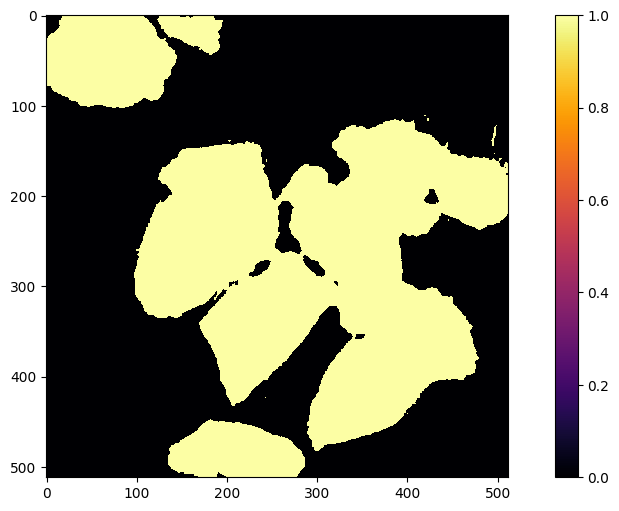

Label


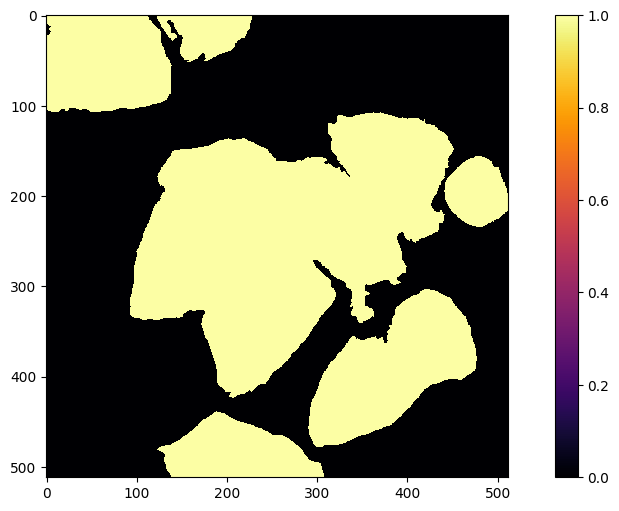

original image


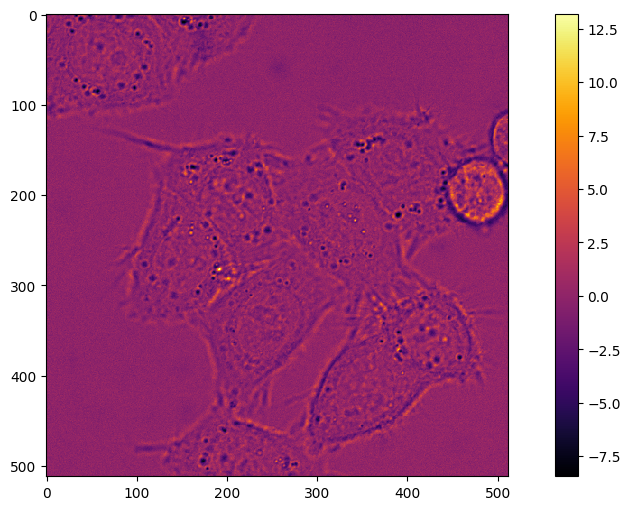

In [32]:
model = RRUNet(channel_list=SIZES,
              len_train=len(train_dataloader_DIC_ST),
              len_val=len(val_dataloader_DIC_ST),
              loss_fn=LogCoshDiceLoss(),
              t=2,
              lr=1e-3,
              dropout=0.1,
              init_type='normal',
              gain=0.02,
              log=True,
              task_name='RRCNN'
        ).to(device)

checkpoint = ModelCheckpoint(dirpath=CHECKPOINT_PATH,
                             save_top_k=2,
                             monitor="Mean Validation MIoU",
                             mode="max"

)
trainer = pl.Trainer(max_epochs=12,
                     log_every_n_steps=1,
                     callbacks=[checkpoint]
)

model = train_model(model, train_dataloader_DIC_ST, val_dataloader_DIC_ST)
plot_example_output(model, val_dataset_DIC_ST)

# RRCNN + Attention

In [81]:
class AttRRUNet(AttentionUNet):
    def __init__(self,
                 channel_list: List[int],
                 crop: bool = None,
                 loss_fn: torch.nn = nn.CrossEntropyLoss(),
                 t: int = 2,
                 lr: float = 1e-3,
                 betas: Tuple[float, float] = (0.9, 0.999),
                 kernel_size: int = 3,
                 dropout: float = 0.1,
                 len_train: int = 1,
                 len_val: int = 1,
                 init_type: str = "normal",
                 gain: float = 0.01,
                 log: bool = False,
                 task_name: str = None):

        super().__init__(
            channel_list=channel_list,
            crop=crop,
            loss_fn=loss_fn,
            lr=lr,
            betas=betas,
            kernel_size=kernel_size,
            dropout=dropout,
            len_train=len_train,
            len_val=len_val,
            init_type=init_type,
            gain=gain,
            log=log,
            task_name=task_name
        )

        # Encoder with RRCNN
        self.channel_sizes = [(channel_list[i], channel_list[i+1]) for i in range(len(channel_list)-1)]
        self.bottom_path = nn.ModuleList([
            RRCNN_block(c_in, c_out, t, kernel_size, dropout)
            for c_in, c_out in self.channel_sizes
        ])

        # Bottleneck with RRCNN
        self.bottleneck = RRCNN_block(channel_list[-1], channel_list[-1], t, kernel_size, dropout)

        # Decoder with RRCNN
        self.channel_sizes[0] = (2, channel_list[1])
        self.channel_sizes = list(reversed(self.channel_sizes))
        self.up_convs = nn.ModuleList()
        self.top_path = nn.ModuleList()
        for out_ch, in_ch in self.channel_sizes:
            self.up_convs.append(nn.ConvTranspose2d(in_ch, in_ch, 2, stride=2))
            self.top_path.append(RRCNN_block(in_ch, out_ch, t, kernel_size, dropout))

        # Reinitialize weights
        self.apply(lambda m: init_weights(m, init_type, gain))

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: UserWarning:

Checkpoint directory /content/models exists and is not empty.

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name             | Type        | Params | Mode 
---------------------------------------------------------
0 | loss_fn          | ComboLoss   | 0      | train
1 | bottom_path      | ModuleList  | 29.0 K | train
2 | pool             | Max

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Epoch 0, Validation loss: 0.3981958230336507, Validation MIoU: 0.10990600287914276


Training: |          | 0/? [00:00<?, ?it/s]


█████████████████████████████████ 100% | 5.03/5.03 MB [00:00<00:00, 14.92MB/s]: 


...

Validation: |          | 0/? [00:00<?, ?it/s]



█████████████████████████████████ 100% | 5.19/5.19 MB [00:00<00:00, 14.98MB/s]: 
INFO: `Trainer.fit` stopped: `max_epochs=16` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=16` reached.


Epoch 15, Validation loss: 0.572059710820516, Validation MIoU: 0.21614697575569153
Epoch 15, Training loss: 0.3000729013056982, Training MIoU: 0.8539742231369019


██████████████████████████████████ 100% | 5.20/5.2 MB [00:00<00:00, 15.69MB/s]: 


Model output


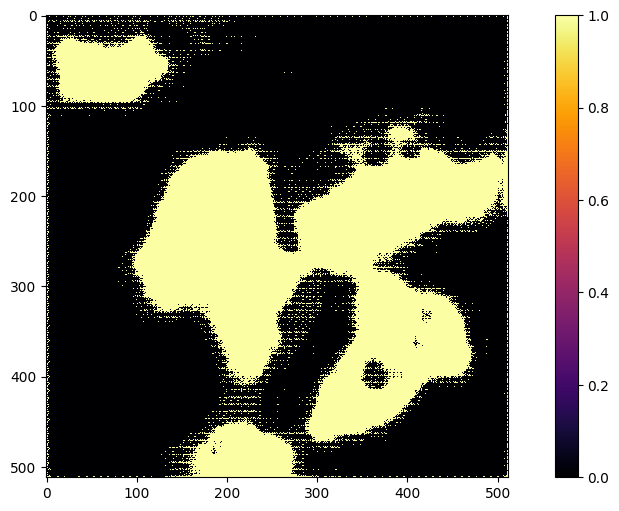

Label


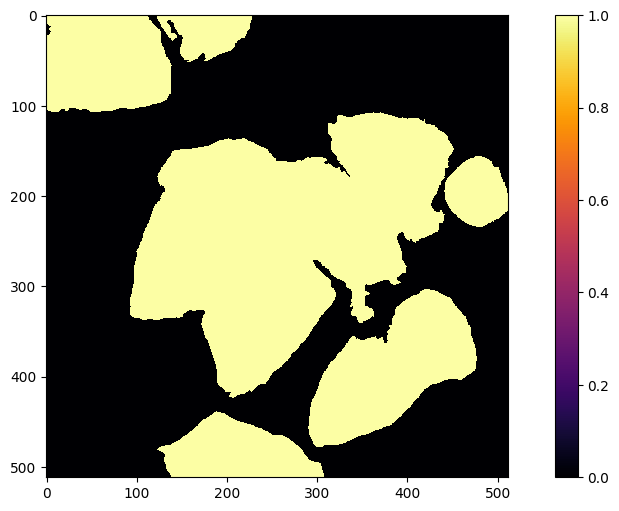

original image


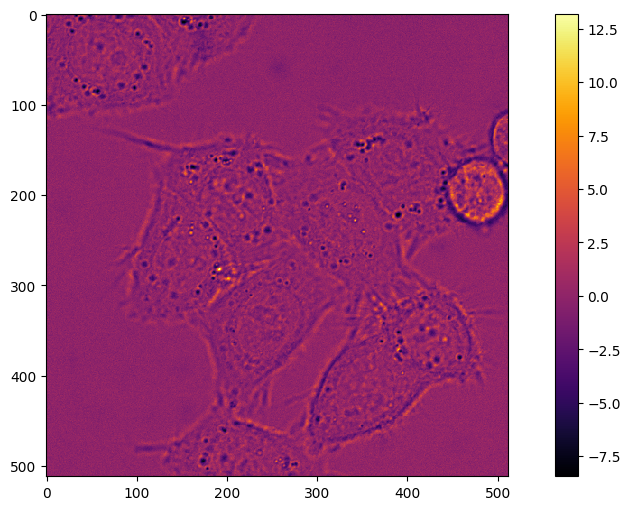

In [70]:
model = AttRRUNet(channel_list=SIZES,
                  len_train=len(train_dataloader_DIC_ST),
                  len_val=len(val_dataloader_DIC_ST),
                  loss_fn=ComboLoss(alpha=0.5),
                  t=2,
                  lr=1e-4,
                  dropout=0.01,
                  init_type='normal',
                  gain=0.03,
                  log=True,
                  task_name='Attention-RRCNN'
                  ).to(device)

checkpoint = ModelCheckpoint(dirpath=CHECKPOINT_PATH,
                             save_top_k=2,
                             monitor="Mean Validation MIoU",
                             mode="max"

)
trainer = pl.Trainer(max_epochs=16,
                     log_every_n_steps=1,
                     callbacks=[checkpoint]
)

model = train_model(model, train_dataloader_DIC_ST, val_dataloader_DIC_ST)
plot_example_output(model, val_dataset_DIC_ST)

# BiFPN https://arxiv.org/pdf/1911.09070

In [73]:
class BiFPN_Block(nn.Module):
    def __init__(self, in_channels, out_channels, residual_channels, kernel_size=3, dropout=0.1, epsilon=1e-8):
        super().__init__()
        self.epsilon = epsilon
        self.w = nn.Parameter(torch.Tensor(2, 1))
        nn.init.constant_(self.w, 1.0)

        if residual_channels != in_channels:
            self.residual_conv = nn.Conv2d(residual_channels, in_channels, kernel_size=1)
        else:
            self.residual_conv = nn.Identity()

        padding = kernel_size // 2
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding, bias=True)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding, bias=True)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding, bias=True)
        self.bn3 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout(p=dropout)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, residual):
        residual = self.residual_conv(residual)
        w = torch.softmax(self.w, dim=0)

        fused = (w[0] * x + w[1] * residual) / (w.sum() + self.epsilon)

        out = self.relu(self.bn1(self.conv1(fused)))
        out = self.dropout(out)
        residual_conv = out
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.dropout(out)
        out = self.relu(self.bn3(self.conv3(out)))
        out = self.dropout(out)
        return out + residual_conv

In [82]:
class BiFPNUNet(UNet):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        # Calculate residual channels from original encoder structure
        original_encoder_channel_sizes = [
            (self.channel_list[i], self.channel_list[i+1])
            for i in range(len(self.channel_list)-1)
        ]
        residual_channels = [c_out for (_, c_out) in original_encoder_channel_sizes][::-1]

        # Replace decoder's top_path with BiFPN blocks
        self.top_path = nn.ModuleList()
        for idx, (out_ch, in_ch) in enumerate(self.channel_sizes):
            self.top_path.append(
                BiFPN_Block(
                    in_channels=in_ch,
                    out_channels=out_ch,
                    residual_channels=residual_channels[idx],
                    kernel_size=self.kernel_size,
                    dropout=self.dropout
                )
            )

    def forward(self, x):
        residuals = []
        for block in self.bottom_path:
            x = block(x)
            residuals.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        residuals = residuals[::-1]

        for idx, block in enumerate(self.top_path):
            x = self.up_convs[idx](x)
            x = block(x, residuals[idx])

        return F.softmax(x, dim=1)

ClearML Task: created new task id=bdb38e4ff5924db79b896e24663e4ce3
ClearML results page: https://app.clear.ml/projects/5bef593faa9547b598bd6a01eea31fc8/experiments/bdb38e4ff5924db79b896e24663e4ce3/output/log


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: UserWarning:

Checkpoint directory /content/models exists and is not empty.

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name        | Type                | Params | Mode 
------------------------------------------------------------
0 | loss_fn     | ComboLoss           | 0      | train
1 | bottom_path | ModuleList          | 29.0 K | train
2 | pool      

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Epoch 0, Validation loss: 0.3982159694035848, Validation MIoU: 0.3051648736000061


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]



                                            0% | 0.00/5.18 MB [00:00<?, ?MB/s]: INFO: `Trainer.fit` stopped: `max_epochs=16` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=16` reached.
█████████████████████████████████ 100% | 5.18/5.18 MB [00:00<00:00, 15.09MB/s]: 

Epoch 15, Validation loss: 0.4876268804073334, Validation MIoU: 0.43379712104797363
Epoch 15, Training loss: 0.3161135046255021, Training MIoU: 0.8613272309303284



██████████████████████████████████ 100% | 5.20/5.2 MB [00:00<00:00, 15.32MB/s]: 


Model output


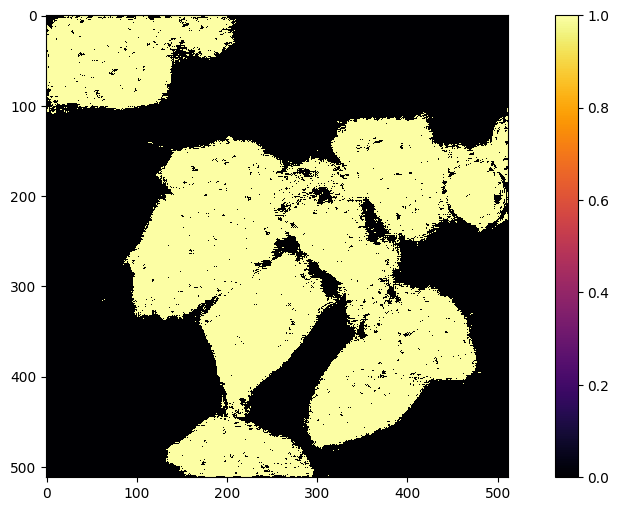

Label


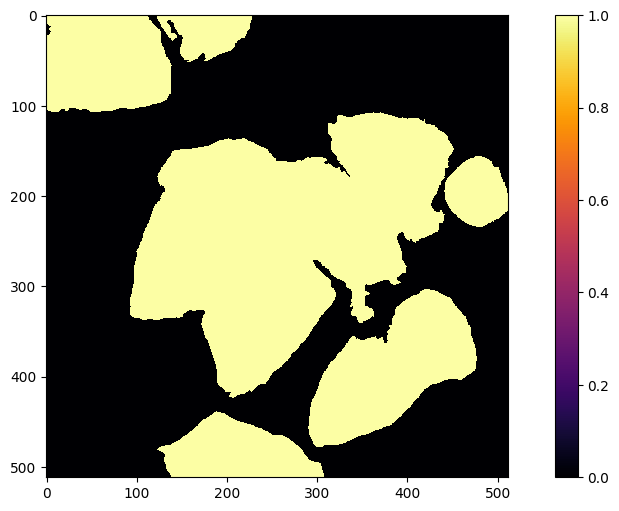

original image


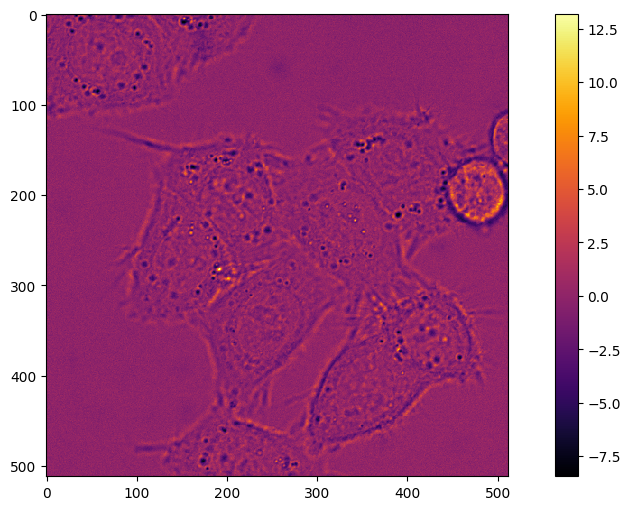

In [71]:
model = BiFPNUNet(channel_list=SIZES,
                        len_train=len(train_dataloader_DIC_ST),
                        len_val=len(val_dataloader_DIC_ST),
                        loss_fn=ComboLoss(alpha=0.5),
                        lr=1e-4,
                        dropout=0.01,
                        init_type='xavier',
                        gain=0.02,
                        log=True,
                        task_name='BiFPN'
                      ).to(device)

checkpoint = ModelCheckpoint(dirpath=CHECKPOINT_PATH,
                             save_top_k=2,
                             monitor="Mean Validation MIoU",
                             mode="max"

)
trainer = pl.Trainer(max_epochs=16,
                     log_every_n_steps=1,
                     callbacks=[checkpoint]
)

model = train_model(model, train_dataloader_DIC_ST, val_dataloader_DIC_ST)
plot_example_output(model, val_dataset_DIC_ST)

# Border Weights https://arxiv.org/pdf/1505.04597

## Experiments

In [ ]:
# Define configs
model_configs = [
    {
        'model_class': UNet,
        'params': {
            'channel_list': [[1, 4, 16, 32], [1, 2, 4, 8, 32], [1, 4, 8, 16, 32], [1, 4, 16, 32, 64]],
            'loss_fn': [DiceLoss(), LogCoshDiceLoss(), ComboLoss(alpha=0.0), ComboLoss(alpha=0.5), ComboLoss(alpha=1.0)],
            'specific_params': {}
        }
    },
    {
        'model_class': UNetPlus,
        'params': {
            'channel_list': [[1, 4, 16, 32], [1, 2, 4, 8, 32], [1, 4, 8, 16, 32], [1, 4, 16, 32, 64]],
            'loss_fn': [DiceLoss(), LogCoshDiceLoss(), ComboLoss(alpha=0.5)],
            'specific_params': {}
        }
    },
    {
        'model_class': AttentionUNet,
        'params': {
            'channel_list': [[1, 4, 16, 32], [1, 2, 4, 8, 32], [1, 4, 8, 16, 32], [1, 4, 16, 32, 64]],
            'loss_fn': [DiceLoss(), LogCoshDiceLoss(), ComboLoss(alpha=0.5)],
            'specific_params': {}
        }
    },
    {
        'model_class': RRUNet,
        'params': {
            'channel_list': [[1, 4, 16, 32], [1, 2, 4, 8, 32], [1, 4, 8, 16, 32], [1, 4, 16, 32, 64]],
            'loss_fn': [DiceLoss(), LogCoshDiceLoss(), ComboLoss(alpha=0.5)],
            'specific_params': {
                't': [2, 3]  # Recurrent steps
            }
        }
    },
     {
        'model_class': AttRRUNet,
        'params': {
            'channel_list': [[1, 4, 16, 32], [1, 2, 4, 8, 32], [1, 4, 8, 16, 32], [1, 4, 16, 32, 64]],
            'loss_fn': [DiceLoss(), LogCoshDiceLoss(), ComboLoss(alpha=0.5)],
            'specific_params': {
                't': [2, 3]  # Recurrent steps
            }
        }
    },
    {
        'model_class': BiFPNUNet,
        'params': {
            'channel_list': [[1, 4, 16, 32], [1, 2, 4, 8, 32], [1, 4, 8, 16, 32], [1, 4, 16, 32, 64]],
            'loss_fn': [DiceLoss(), LogCoshDiceLoss(), ComboLoss(alpha=0.5)],
            'specific_params': {}
        }
    }
]

# Experiment search grid
experiments = []
for config in model_configs:
    base_params = {
        'model_class': [config['model_class']],
        'channel_list': config['params']['channel_list'],
        'loss_fn': config['params']['loss_fn'],
        'lr': [1e-4, 1e-3],
        'dropout': [0.1, 0.2],
        'init_type': ["normal"],
        'gain': [0.02],
        **config['params']['specific_params']
    }

    keys, values = zip(*base_params.items())
    for combination in product(*values):
        experiments.append(dict(zip(keys, combination)))

for i, exp_params in enumerate(experiments):
    print(f"Running Experiment {i+1}/{len(experiments)}")

    model_kwargs = {
        'channel_list': exp_params['channel_list'],
        'len_train': len(train_dataloader_DIC_ST),
        'len_val': len(val_dataloader_DIC_ST),
        'loss_fn': exp_params['loss_fn'],
        'lr': exp_params['lr'],
        'dropout': exp_params['dropout'],
        'init_type': exp_params['init_type'],
        'gain': exp_params['gain']
    }

    if issubclass(exp_params['model_class'], RRUNet):
        model_kwargs['t'] = exp_params.get('t', 2)

    # Create model name
    task_name = f"{exp_params['model_class'].__name__}_" \
                f"lr{exp_params['lr']}_" \
                f"do{exp_params['dropout']}_" \
                f"init{exp_params['init_type']}_" \
                f"gain{exp_params['gain']}_" \
                f"ch{'-'.join(map(str, exp_params['channel_list']))}_" \
                f"loss{exp_params['loss_fn'].__class__.__name__}"

    if 't' in model_kwargs:
        task_name += f"_t{model_kwargs['t']}"

    # Initialize model
    model = exp_params['model_class'](
        **model_kwargs,
        log=True,
        task_name=task_name
    ).to(device)

    checkpoint = ModelCheckpoint(dirpath=CHECKPOINT_PATH,
                             save_top_k=2,
                             monitor="Mean Validation MIoU",
                             mode="max"

                )
    trainer = pl.Trainer(max_epochs=64,
                        log_every_n_steps=1,
                        callbacks=[checkpoint]
    )

    model = train_model(model, train_dataloader_DIC_ST, val_dataloader_DIC_ST)